### Prediction of Flower Species using Gradient Boosting Machines

In [26]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

In [27]:
data=load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

#### Convert to CSV file

In [28]:
df=pd.DataFrame(data.data, columns=data.feature_names)
df["target"]=data.target
df.to_csv("iris_1.csv", index=False)

#### Read CSV

In [29]:
df=pd.read_csv("iris_1.csv")
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### Train Test Split

In [30]:
x=df.drop("target", axis=1)
y=df["target"]
xtrain, xtest, ytrain, ytest= train_test_split(x,y, test_size=0.2, random_state=42, shuffle= True) 

#### Gradient Boosting

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=20,
    learning_rate=0.1,
    random_state=42
)

model.fit(xtrain, ytrain)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,20
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [32]:
print("Training Accuracy:", model.score(xtrain, ytrain))
print("Testing Accuracy:", model.score(xtest, ytest))


Training Accuracy: 1.0
Testing Accuracy: 1.0


### Model evaluation

In [33]:
print("Training Accuracy", model.score(xtrain, ytrain))
print("Accuracy:",model.score(xtest,ytest))

Training Accuracy 1.0
Accuracy: 1.0


In [34]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': xtrain.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values('Importance', ascending=False)
print(importance)


             Feature  Importance
2  petal length (cm)    0.670692
3   petal width (cm)    0.316812
1   sepal width (cm)    0.011702
0  sepal length (cm)    0.000794


In [35]:

from sklearn.tree import export_text

tree = model.estimators_[0, 0]
print(export_text(tree, feature_names=list(xtrain.columns)))


|--- petal length (cm) <= 2.45
|   |--- value: [2.00]
|--- petal length (cm) >  2.45
|   |--- value: [-1.00]



### Feature Importance Visualization

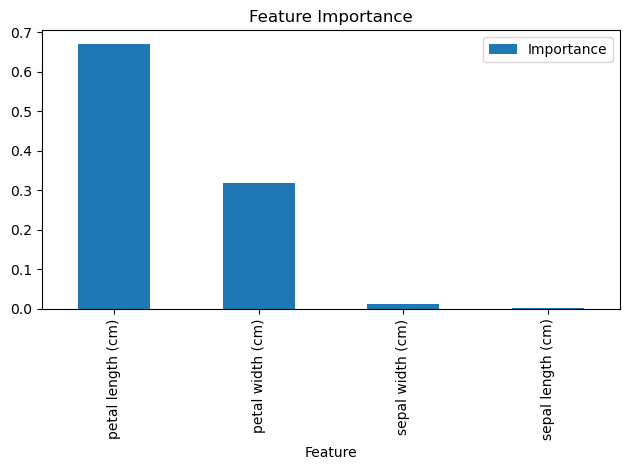

In [36]:
import matplotlib.pyplot as plt

importance.plot(x='Feature', y='Importance', kind='bar')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


In [37]:
print('Gradient Boosting model completed successfully.')

Gradient Boosting model completed successfully.


In [38]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=20,
    random_state=42
)
model.fit(xtrain, ytrain)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,20
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [39]:
print("Training Accuracy", model.score(xtrain, ytrain))
print("Accuracy:",model.score(xtest,ytest))

Training Accuracy 1.0
Accuracy: 1.0


In [40]:
from lightgbm import LGBMClassifier
model= LGBMClassifier(
    n_estimators=20,
    learning_rate=0.1,
    random_state=42)
model.fit(xtrain, ytrain)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000617 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 4
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.073920
[LightGBM] [Info] Start training from score -1.123930
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,20
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
# Display first 3 trees from GradientBoostingClassifier
from sklearn.tree import export_text

for i in range(min(3, len(model.estimators_))):
    print(f"\nTree {i+1}")
    print(export_text(model.estimators_[i,0], feature_names=list(xtrain.columns)))

#### Catboost - Works for categorical 

In [59]:
import seaborn as sns
from catboost import CatBoostClassifier

### Load and read dataset

In [60]:
df= sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [61]:
df.shape

(891, 15)

In [62]:
df= df[["survived", "pclass", "sex", "age", "fare", "embarked", "class", "who"]]

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])

### Train test split

In [63]:
x= df.drop("survived", axis =1)
y=df["survived"]
cat_features=["sex","embarked","class","who"]
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

### Building CatBoost Model

In [64]:
model= CatBoostClassifier( iterations=20, learning_rate=0.1, depth=6,verbose=0)
model.fit(xtrain,ytrain, cat_features=cat_features)

CatBoostClassifier(depth=6, iterations=20, learning_rate=0.1, verbose=0)

### Model Evaluation

In [65]:
print("Traininng Accuracy:", model.score(xtrain, ytrain))
print("Accuracy:",model.score(xtest,ytest))

Traininng Accuracy: 0.8314606741573034
Accuracy: 0.8100558659217877
